In [1]:
# Grundläggande bibliotek
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar100.load_data(label_mode="coarse")

y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Antal klasser:", len(np.unique(y_train_full)))
print("Klasser:", np.unique(y_train_full))

X_train_full: (50000, 32, 32, 3)
y_train_full: (50000,)
X_test: (10000, 32, 32, 3)
y_test: (10000,)
Antal klasser: 20
Klasser: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


c:\Users\joaki\Desktop\DL_kurs\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
class_names = [
    "aquatic mammals",
    "fish",
    "flowers",
    "food containers",
    "fruit and vegetables",
    "household electrical devices",
    "household furniture",
    "insects",
    "large carnivores",
    "large man-made outdoor things",
    "large natural outdoor scenes",
    "large omnivores and herbivores",
    "medium mammals",
    "non-insect invertebrates",
    "people",
    "reptiles",
    "small mammals",
    "trees",
    "vehicles 1",
    "vehicles 2"
]

for i, name in enumerate(class_names):
    print(i, name)

0 aquatic mammals
1 fish
2 flowers
3 food containers
4 fruit and vegetables
5 household electrical devices
6 household furniture
7 insects
8 large carnivores
9 large man-made outdoor things
10 large natural outdoor scenes
11 large omnivores and herbivores
12 medium mammals
13 non-insect invertebrates
14 people
15 reptiles
16 small mammals
17 trees
18 vehicles 1
19 vehicles 2


In [4]:
class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,aquatic mammals,2500
1,1,fish,2500
2,2,flowers,2500
3,3,food containers,2500
4,4,fruit and vegetables,2500
5,5,household electrical devices,2500
6,6,household furniture,2500
7,7,insects,2500
8,8,large carnivores,2500
9,9,large man-made outdoor things,2500


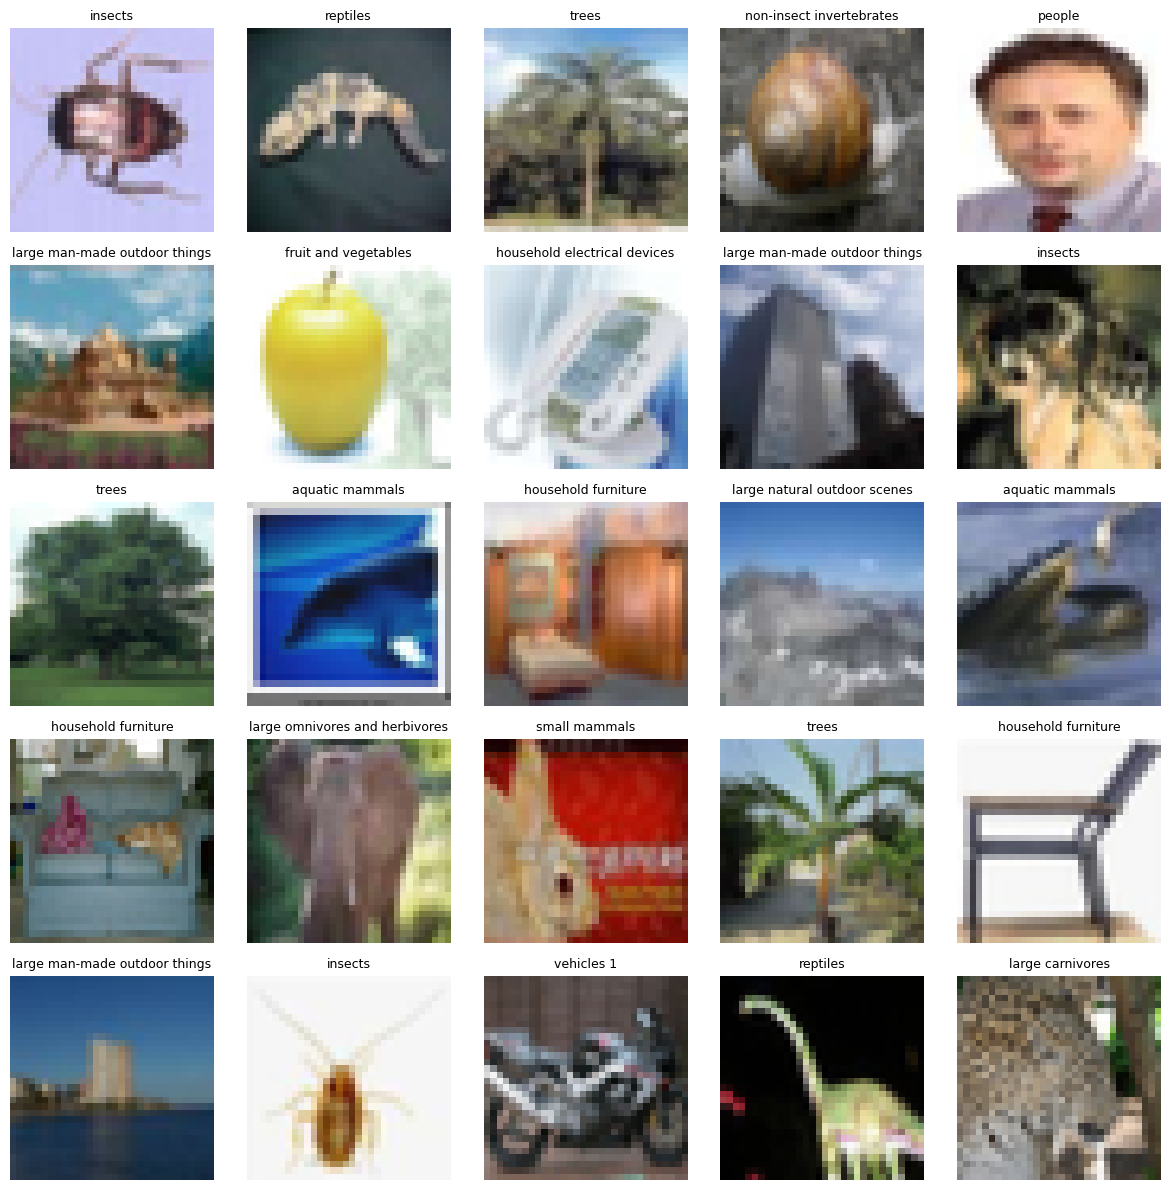

In [5]:
def  plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index])
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


plot_image_grid(
    X_train_full,
    y_train_full,
    class_names,
    n_images=25
)

In [6]:
def create_balanced_subset(X, y, samples_per_class=300, random_state=42):

    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    X_train_full,
    y_train_full,
    samples_per_class=300,
    random_state=42
)

print("X_subset_raw:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)

X_subset_raw: (6000, 32, 32, 3)
y_subset: (6000,)


In [7]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:", X_val_raw.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train_raw: (4800, 32, 32, 3)
X_val_raw: (1200, 32, 32, 3)
y_train: (4800,)
y_val: (1200,)


In [8]:
X_train = X_train_raw.astype("float32") / 255.0
X_val = X_val_raw.astype("float32") / 255.0

X_test_norm = X_test.astype("float32") / 255.0

print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_train shape: (4800, 32, 32, 3)


In [9]:
def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [11]:
num_classes = len(class_names)

baseline_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 546,388 (2.08 MB)

 Trainable params: 546,388 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1346 - loss: 2.8134 - val_accuracy: 0.1892 - val_loss: 2.6370
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2400 - loss: 2.4832 - val_accuracy: 0.2625 - val_loss: 2.4443
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3123 - loss: 2.2708 - val_accuracy: 0.2875 - val_loss: 2.3261
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3673 - loss: 2.0995 - val_accuracy: 0.3100 - val_loss: 2.2716
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4015 - loss: 1.9636 - val_accuracy: 0.3108 - val_loss: 2.2615
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4323 - loss: 1.8431 - val_accuracy: 0.3242 - val_loss: 2.2422
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4769 - loss: 1.7178 - val_accuracy: 0.3233 - val_loss: 2.2298
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5175 - loss: 1.5840 - val_accuracy: 0.3325 - val_loss:

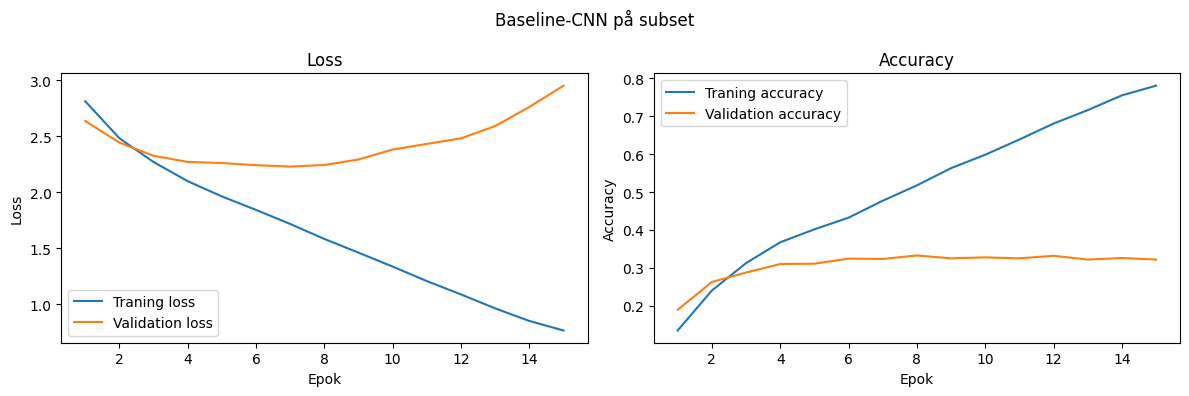

In [12]:
start_time = time.time()

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

baseline_trainig_time = time.time() - start_time

print(f"Träningstid för baseline på subset: {baseline_trainig_time / 60:.2f} minuter")

plot_history(baseline_history, title="Baseline-CNN på subset")

In [13]:
baseline_history_df = pd.DataFrame(baseline_history.history)

best_epoch = baseline_history_df["val_loss"].idxmin() + 1
best_val_loss = baseline_history_df["val_loss"].min()
best_val_accuracy = baseline_history_df["val_accuracy"].iloc[best_epoch - 1]

print(f"Bästa validation loss vid epok: {best_epoch}")
print(f"Bästa validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy vid den epoken: {best_val_accuracy:.4f}")

Bästa validation loss vid epok: 7
Bästa validation loss: 2.2298
Validation accuracy vid den epoken: 0.3233


In [14]:
def predict_classes(model, X):
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return y_pred, y_proba

baseline_val_pred, baseline_val_proba = predict_classes(
    baseline_model,
    X_val
)

baseline_val_accuracy = accuracy_score(y_val, baseline_val_pred)

print(f"Baseline validation accuracy: {baseline_val_accuracy:.4f}")

Baseline validation accuracy: 0.3217


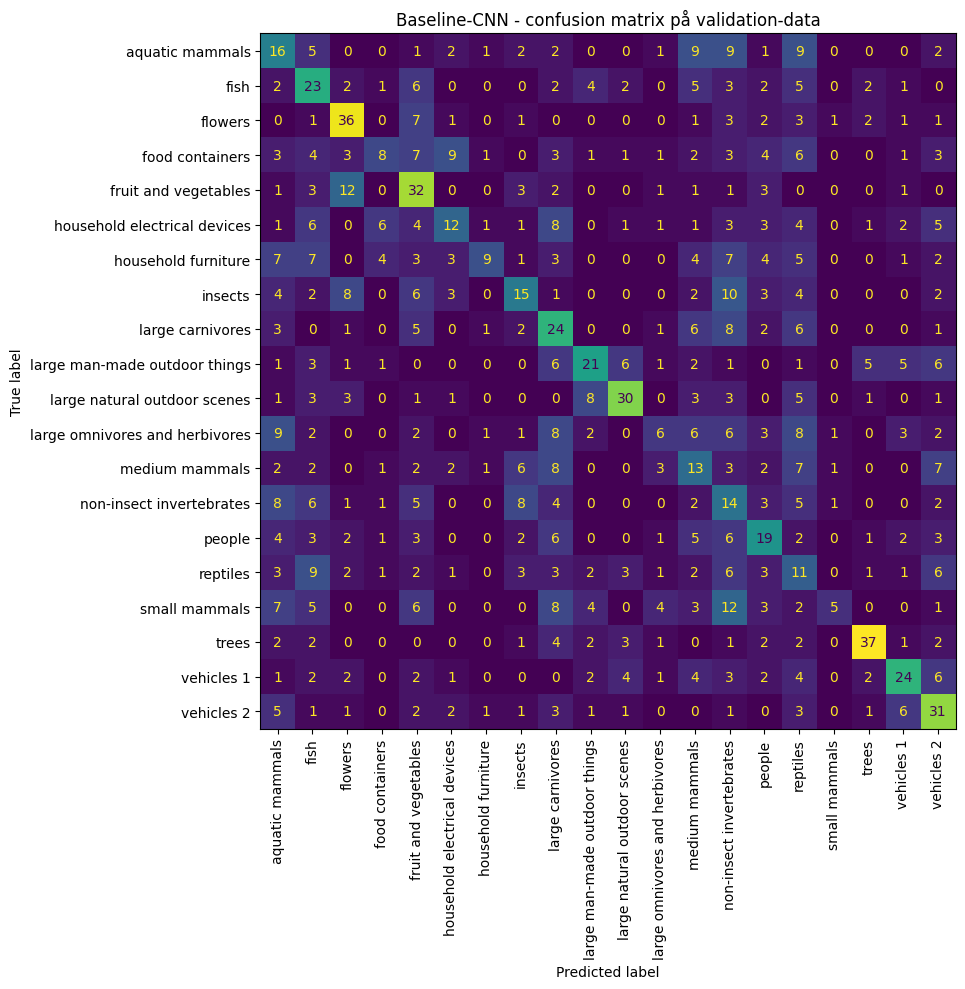

In [16]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

baseline_cm = plot_confusion_matrix(
    y_val,
    baseline_val_pred,
    class_names,
    title="Baseline-CNN - confusion matrix på validation-data"
)

In [17]:
def calculate_per_classs_accuracy(cm, class_names):

    support = cm.sum(axis=1)
    correct = np.diag(cm)

    accuracy = np.divide(
        correct,
        support,
        out=np.zeros_like(correct, dtype=float),
        where=support != 0
    )

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": correct,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")


baseline_per_class = calculate_per_classs_accuracy(
    baseline_cm,
    class_names
)

baseline_per_class

,class_id,class_name,support,correct,accuracy
16,16,small mammals,60,5,0.083333
11,11,large omnivores and herbivores,60,6,0.100000
3,3,food containers,60,8,0.133333
6,6,household furniture,60,9,0.150000
15,15,reptiles,60,11,0.183333
5,5,household electrical devices,60,12,0.200000
12,12,medium mammals,60,13,0.216667
13,13,non-insect invertebrates,60,14,0.233333
7,7,insects,60,15,0.250000
0,0,aquatic mammals,60,16,0.266667


In [18]:
def get_most_confused_pairs(cm, class_names, top_n=10):
    pairs = []

    for true_class in range(cm.shape[0]):
        for predicted_class in range(cm.shape[1]):
            if true_class == predicted_class:
                continue

            count = cm[true_class, predicted_class]

            if count > 0:
                pairs.append({
                    "true_class_id": true_class,
                    "true_class": class_names[true_class],
                    "predicted_class_id": predicted_class,
                    "predicted_class": class_names[predicted_class],
                    "count": count
                })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pairs_df

    return pairs_df.sort_values("count", ascending=False).head(top_n)

baseline_confusions = get_most_confused_pairs(
    baseline_cm,
    class_names
)

baseline_confusions

,true_class_id,true_class,predicted_class_id,predicted_class,count
216,16,small mammals,13,non-insect invertebrates,12
55,4,fruit and vegetables,2,flowers,12
99,7,insects,13,non-insect invertebrates,10
138,11,large omnivores and herbivores,0,aquatic mammals,9
7,0,aquatic mammals,12,medium mammals,9
10,0,aquatic mammals,15,reptiles,9
8,0,aquatic mammals,13,non-insect invertebrates,9
193,15,reptiles,1,fish,9
41,3,food containers,5,household electrical devices,9
212,16,small mammals,8,large carnivores,8


Antal felklassificerade exempel: 814


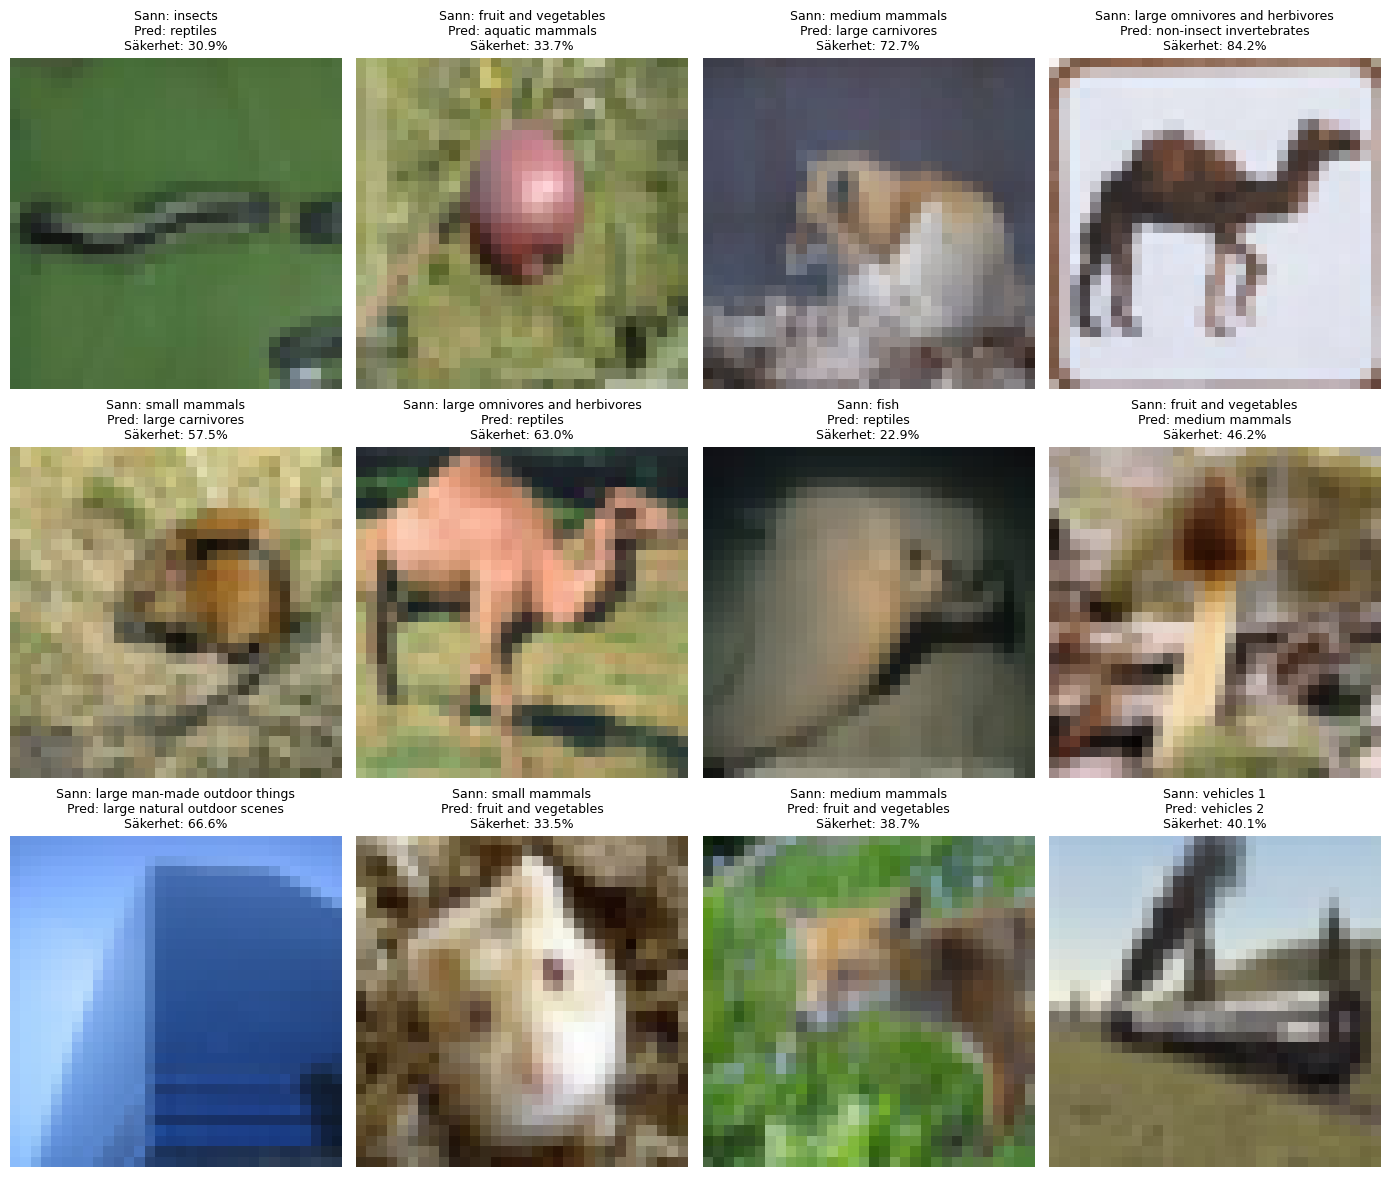

In [19]:
def plot_misclassified_examples(
    X,
    y_true,
    y_pred,
    y_proba,
    class_names,
    n_images=12,
    random_state=42
):
    """
    Visar felklassificerade bilder.

    X:
        Bilddata, normaliserad eller i 0-1-format.

    y_true:
        Sanna labels.

    y_pred:
        Predikterade labels.

    y_proba:
        Sannolikheter från modellen.

    class_names:
        Lista med klassnamn.

    n_images:
        Antal felklassificerade bilder att visa.

    random_state:
        Seed för reproducerbart urval.
    """

    error_indices = np.where(y_true != y_pred)[0]

    print(f"Antal felklassificerade exempel: {len(error_indices)}")

    if len(error_indices) == 0:
        print("Inga felklassificerade exempel att visa.")
        return

    rng = np.random.default_rng(random_state)

    chosen_indices = rng.choice(
        error_indices,
        size=min(n_images, len(error_indices)),
        replace=False
    )

    cols = 4
    rows = int(np.ceil(len(chosen_indices) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_true[data_index]
        pred_label = y_pred[data_index]
        confidence = y_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X[data_index])
        plt.title(
            f"Sann: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_misclassified_examples(
    X_val,
    y_val,
    baseline_val_pred,
    baseline_val_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [24]:
def build_model(num_classes, learning_rate=0.001):
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss = keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

def make_early_stopping(patience=5):
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )
    
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

improved_model = build_model(num_classes=num_classes)

improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,276 (1.54 MB)

 Trainable params: 404,276 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0644 - loss: 2.9615 - val_accuracy: 0.1150 - val_loss: 2.8590
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1215 - loss: 2.8127 - val_accuracy: 0.1608 - val_loss: 2.7074
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1704 - loss: 2.6974 - val_accuracy: 0.1942 - val_loss: 2.5912
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1733 - loss: 2.6136 - val_accuracy: 0.2033 - val_loss: 2.5539
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2017 - loss: 2.5656 - val_accuracy: 0.2217 - val_loss: 2.4927
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2131 - loss: 2.5097 - val_accuracy: 0.2367 - val_loss: 2.4460
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2387 - loss: 2.4490 - val_accuracy: 0.2575 - val_loss: 2.4001
Epoch 8/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2465 - loss: 2.4048 - val_accuracy: 0.2767 - v

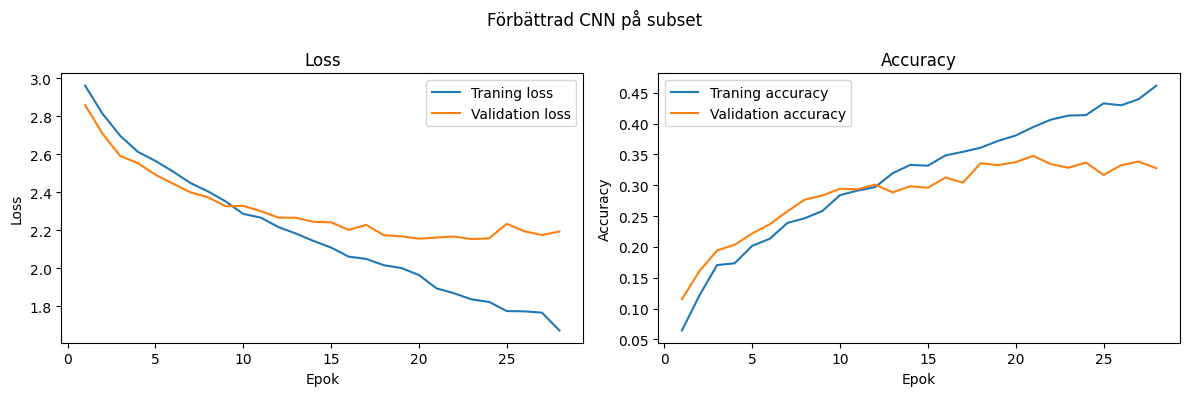

In [25]:
start_time = time.time()

improved_history = improved_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[make_early_stopping(patience=5)]
)

subset_training_time = time.time() - start_time

print(f"Träningstid för förbättrad modell på subset: {subset_training_time / 60:.2f} minuter")

plot_history(improved_history, title="Förbättrad CNN på subset")

In [26]:
improved_val_pred, improved_val_proba = predict_classes(
    improved_model,
    X_val
)

improved_val_accuracy = accuracy_score(y_val, improved_val_pred)

print(f"Baseline validation accuracy: { baseline_val_accuracy:.4f}")
print(f"Improved validation accuracy: { improved_val_accuracy:.4f}")

Baseline validation accuracy: 0.3217
Improved validation accuracy: 0.3283


In [27]:
def summarize_history(history, name, val_accuracy):
    history_df = pd.DataFrame(history.history)

    return {
        "model": name,
        "epochs_trained": len(history_df),
        "best_val_loss": history_df["val_loss"].min(),
        "best_val_accuracy": history_df["val_accuracy"].max(),
        "final_val_accuracy": val_accuracy
    }


comparison = pd.DataFrame([
    summarize_history(
        baseline_history,
        "Baseline CNN",
        baseline_val_accuracy
    ),
    summarize_history(
        improved_history,
        "Improved CNN",
        improved_val_accuracy
    )
])

comparison

,model,epochs_trained,best_val_loss,best_val_accuracy,final_val_accuracy
0,Baseline CNN,15,2.229821,0.3325,0.321667
1,Improved CNN,28,2.154131,0.3475,0.328333


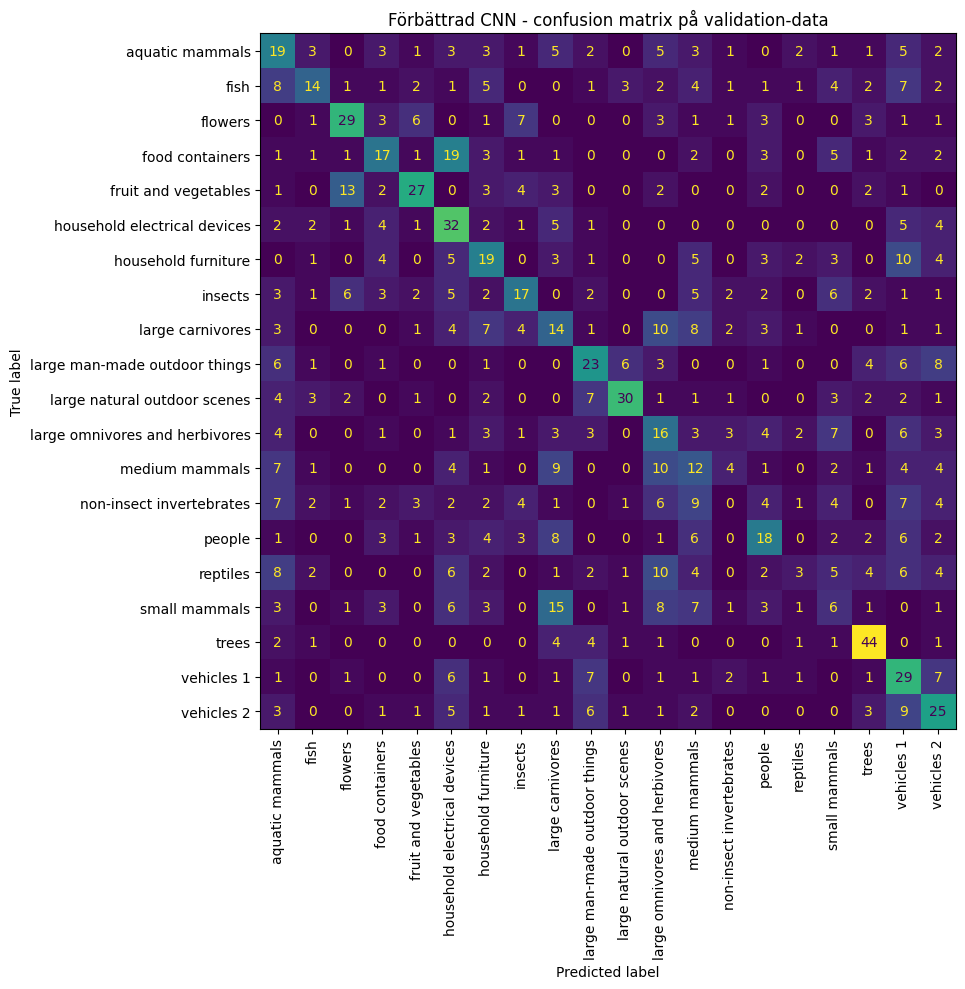

,class_id,class_name,support,correct,accuracy
13,13,non-insect invertebrates,60,0,0.000000
15,15,reptiles,60,3,0.050000
16,16,small mammals,60,6,0.100000
12,12,medium mammals,60,12,0.200000
8,8,large carnivores,60,14,0.233333
1,1,fish,60,14,0.233333
11,11,large omnivores and herbivores,60,16,0.266667
7,7,insects,60,17,0.283333
3,3,food containers,60,17,0.283333
14,14,people,60,18,0.300000


In [28]:
improved_cm = plot_confusion_matrix(
    y_val,
    improved_val_pred,
    class_names,
    title= "Förbättrad CNN - confusion matrix på validation-data"
)

improved_per_class = calculate_per_classs_accuracy(
    improved_cm,
    class_names
)

improved_per_class

In [29]:
improved_confusions = get_most_confused_pairs(
    improved_cm,
    class_names,
    top_n=10
)

print("Vanligaste förväxlingar - baseline:")
display(baseline_confusions)

print("Vanligaste förväxlingar - förbättrad modell:")
display(improved_confusions)

Vanligaste förväxlingar - baseline:


,true_class_id,true_class,predicted_class_id,predicted_class,count
216,16,small mammals,13,non-insect invertebrates,12
55,4,fruit and vegetables,2,flowers,12
99,7,insects,13,non-insect invertebrates,10
138,11,large omnivores and herbivores,0,aquatic mammals,9
7,0,aquatic mammals,12,medium mammals,9
10,0,aquatic mammals,15,reptiles,9
8,0,aquatic mammals,13,non-insect invertebrates,9
193,15,reptiles,1,fish,9
41,3,food containers,5,household electrical devices,9
212,16,small mammals,8,large carnivores,8


Vanligaste förväxlingar - förbättrad modell:


,true_class_id,true_class,predicted_class_id,predicted_class,count
49,3,food containers,5,household electrical devices,19
217,16,small mammals,8,large carnivores,15
60,4,fruit and vegetables,2,flowers,13
205,15,reptiles,11,large omnivores and herbivores,10
89,6,household furniture,18,vehicles 1,10
161,12,medium mammals,11,large omnivores and herbivores,10
112,8,large carnivores,11,large omnivores and herbivores,10
160,12,medium mammals,8,large carnivores,9
260,19,vehicles 2,18,vehicles 1,9
179,13,non-insect invertebrates,12,medium mammals,9


Antal felklassificerade exempel: 806


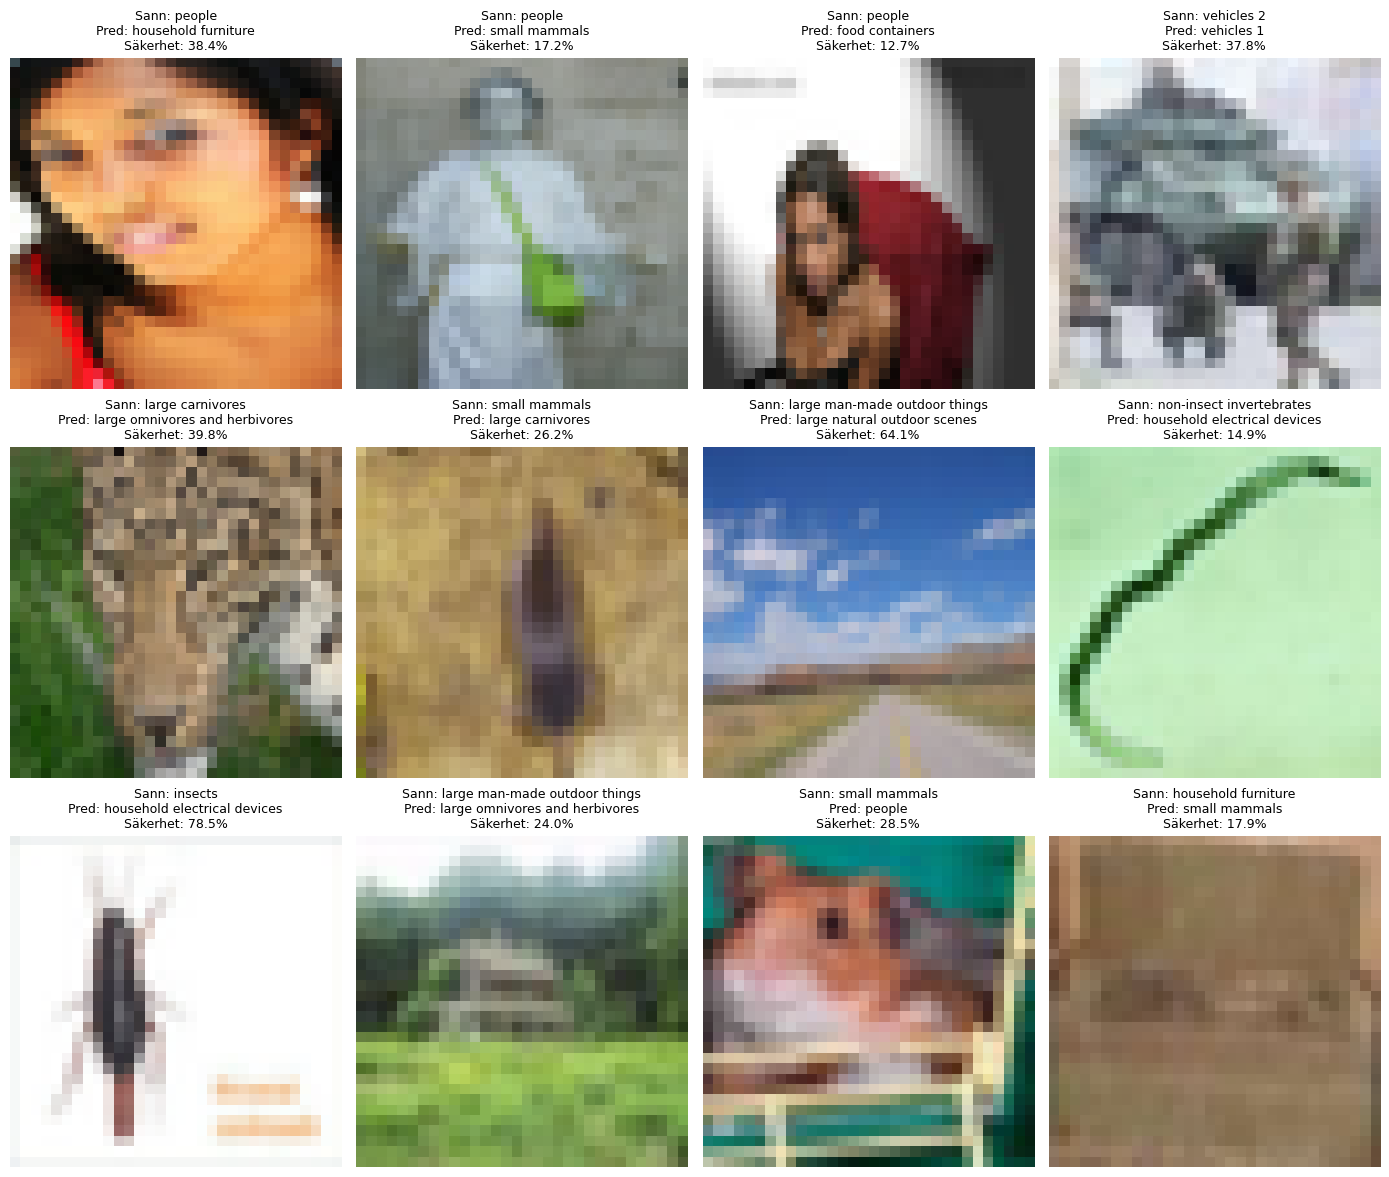

In [30]:
plot_misclassified_examples(
    X_val,
    y_val,
    improved_val_pred,
    improved_val_proba,
    class_names,
    n_images=12,
    random_state=123
)

In [31]:
X_train_full_part_raw, X_val_full_raw, y_train_full_part, y_val_full = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

X_train_full_part = X_train_full_part_raw.astype("float32") / 255.0
X_val_full = X_val_full_raw.astype("float32") / 255.0

print("X_train_full_part:", X_train_full_part.shape)
print("X_val_full:", X_val_full.shape)
print("X_test_norm:", X_test_norm.shape)

X_train_full_part: (45000, 32, 32, 3)
X_val_full: (5000, 32, 32, 3)
X_test_norm: (10000, 32, 32, 3)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1699 - loss: 2.6577 - val_accuracy: 0.2818 - val_loss: 2.3099
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2832 - loss: 2.3161 - val_accuracy: 0.3300 - val_loss: 2.1160
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3331 - loss: 2.1579 - val_accuracy: 0.3748 - val_loss: 1.9937
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3660 - loss: 2.0415 - val_accuracy: 0.4092 - val_loss: 1.8907
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3872 - loss: 1.9676 - val_accuracy: 0.4318 - val_loss: 1.7798
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4104 - loss: 1.8940 - val_accuracy: 0.4440 - val_loss: 1.7634
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4308 - loss: 1.8249 - val_accuracy: 0.4648 - val_loss: 1.7186
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.4466 - loss: 1.7707 - val_accu

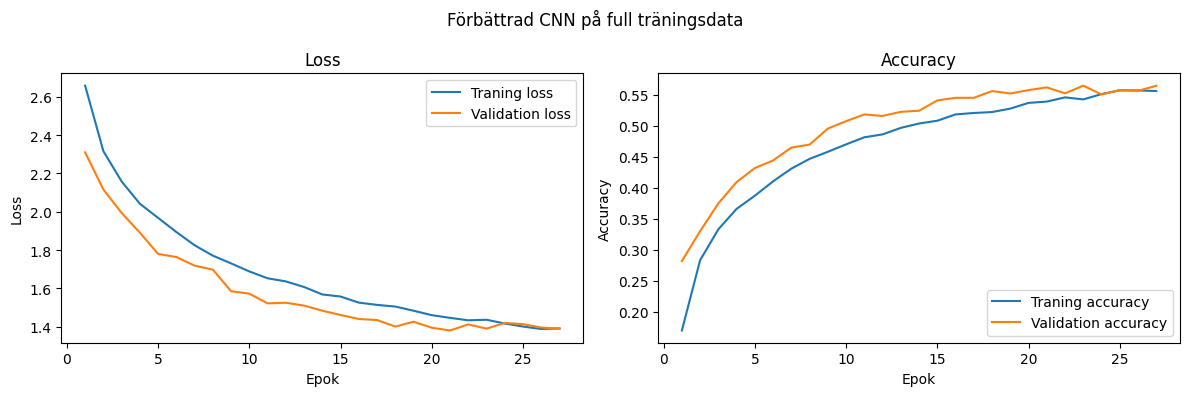

In [32]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

final_model = build_model(num_classes=num_classes)

start_time = time.time()

final_history = final_model.fit(
    X_train_full_part,
    y_train_full_part,
    validation_data=(X_val_full, y_val_full),
    epochs=50,
    batch_size=64,
    callbacks=[make_early_stopping(patience=6)]
)

full_training_time = time.time() - start_time

print(f"Träningstid på full data: {full_training_time / 60:.2f} minuter")

plot_history(final_history, title="Förbättrad CNN på full träningsdata")

In [33]:
test_loss, test_accuracy = final_model.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Final model - test loss: {test_loss:.4f}")
print(f"Final model - test accuracy: {test_accuracy:.4f}")

Final model - test loss: 1.3681
Final model - test accuracy: 0.5703


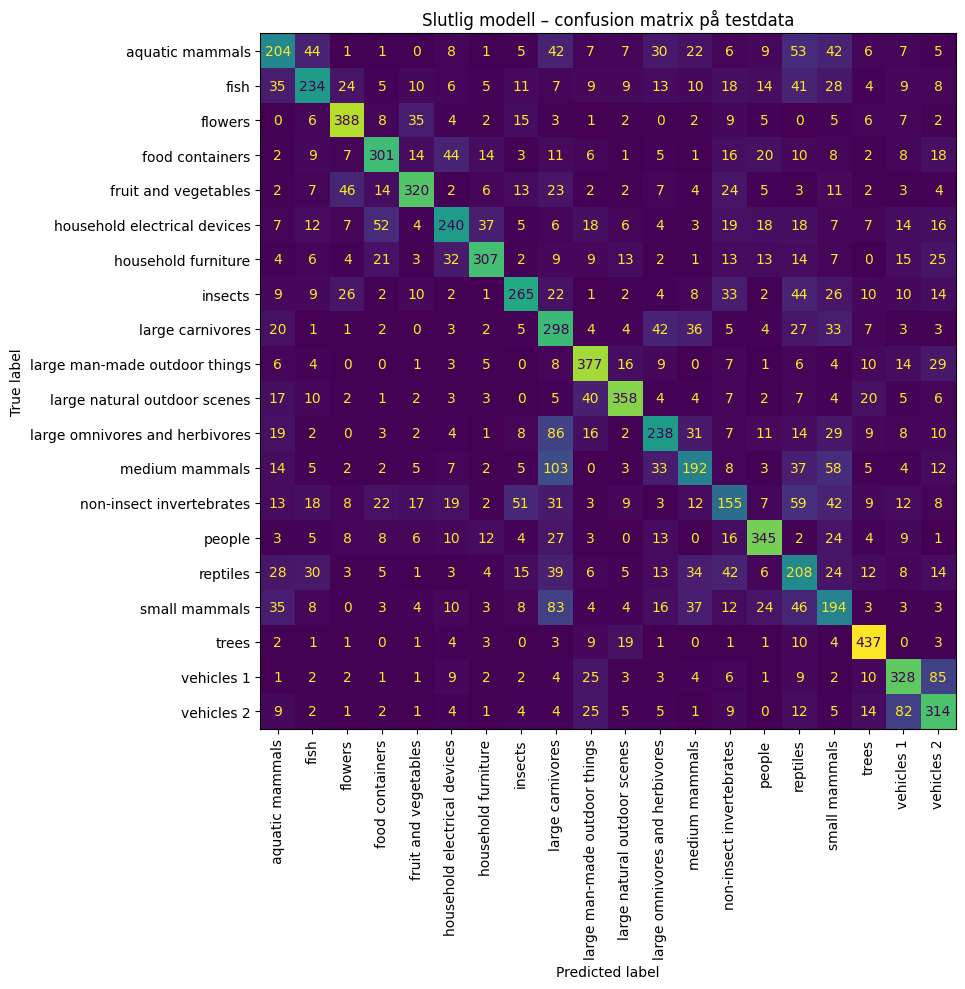

,class_id,class_name,support,correct,accuracy
13,13,non-insect invertebrates,500,155,0.310
12,12,medium mammals,500,192,0.384
16,16,small mammals,500,194,0.388
0,0,aquatic mammals,500,204,0.408
15,15,reptiles,500,208,0.416
1,1,fish,500,234,0.468
11,11,large omnivores and herbivores,500,238,0.476
5,5,household electrical devices,500,240,0.480
7,7,insects,500,265,0.530
8,8,large carnivores,500,298,0.596


In [35]:
final_test_pred, final_test_proba = predict_classes(
    final_model,
    X_test_norm
)

final_test_cm = plot_confusion_matrix(
    y_test,
    final_test_pred,
    class_names,
    title="Slutlig modell – confusion matrix på testdata"
)

final_test_per_class = calculate_per_classs_accuracy(
    final_test_cm,
    class_names
)

final_test_per_class

In [36]:
final_test_confusions = get_most_confused_pairs(
    final_test_cm,
    class_names,
    top_n=10
)

final_test_confusions

,true_class_id,true_class,predicted_class_id,predicted_class,count
224,12,medium mammals,8,large carnivores,103
205,11,large omnivores and herbivores,8,large carnivores,86
340,18,vehicles 1,19,vehicles 2,85
296,16,small mammals,8,large carnivores,83
358,19,vehicles 2,18,vehicles 1,82
248,13,non-insect invertebrates,15,reptiles,59
230,12,medium mammals,16,small mammals,58
13,0,aquatic mammals,15,reptiles,53
94,5,household electrical devices,3,food containers,52
241,13,non-insect invertebrates,7,insects,51


Antal felklassificerade exempel: 4297


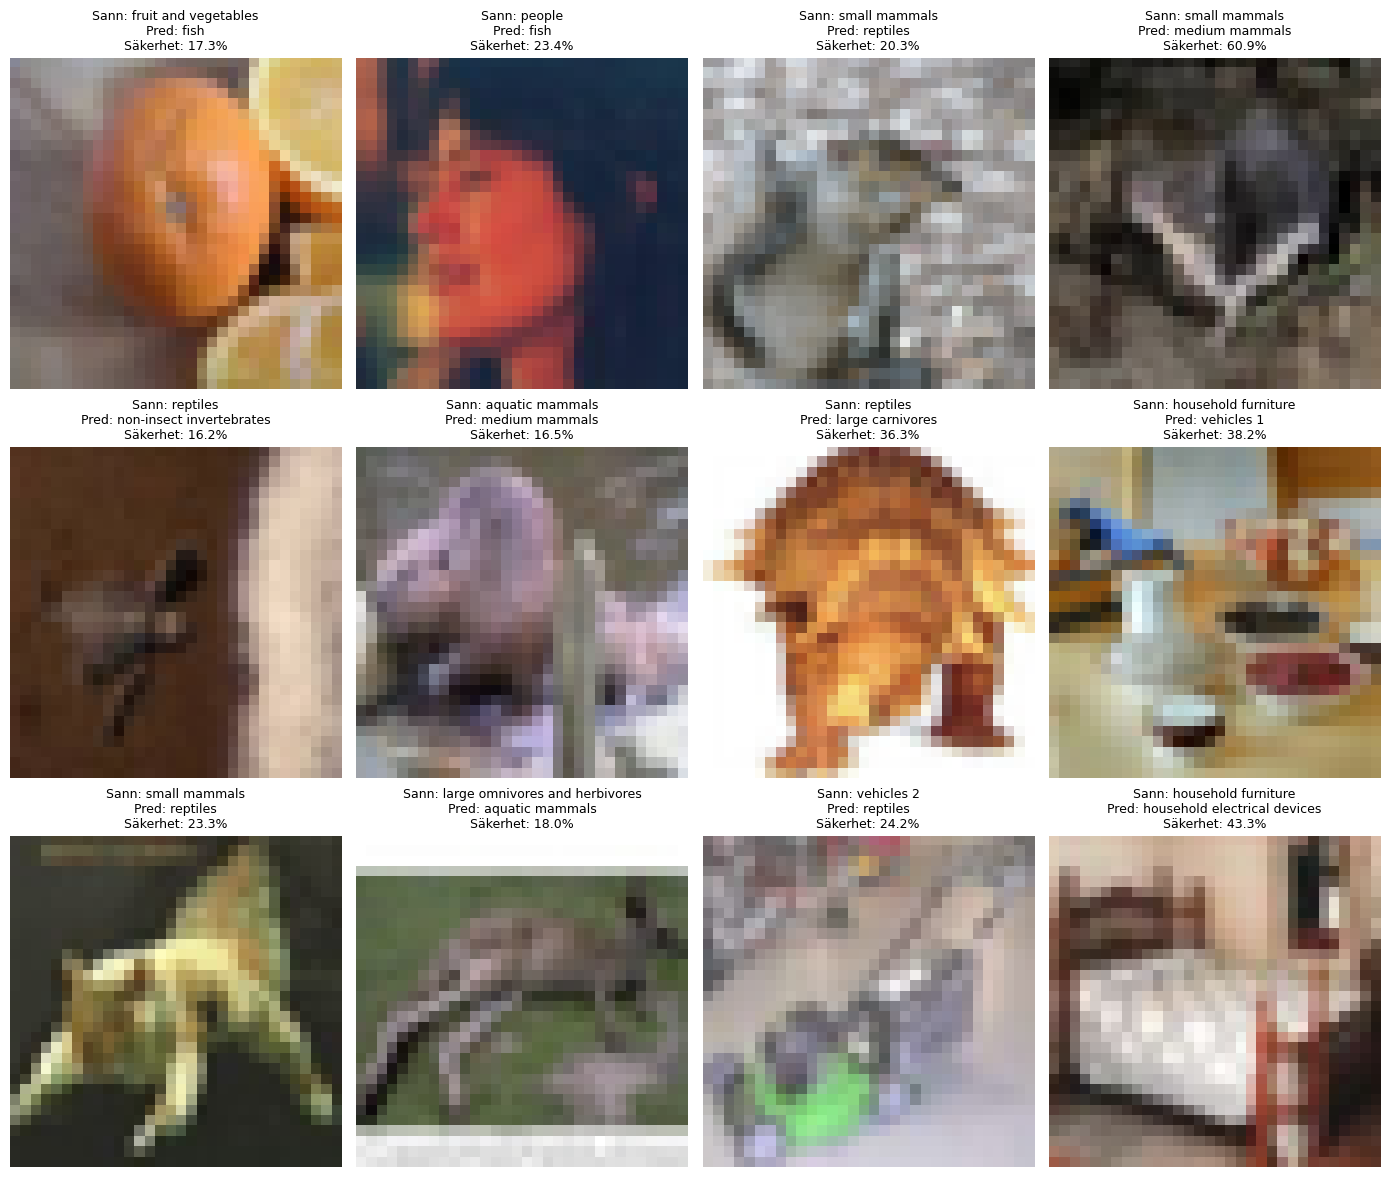

In [37]:
plot_misclassified_examples(
    X_test_norm,
    y_test,
    final_test_pred,
    final_test_proba,
    class_names,
    n_images=12,
    random_state=42
)